In [74]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.api as sm
from scipy.stats import false_discovery_control

#### Load & Clean Data

In [75]:
## Read ruler measurements
ruler = pd.read_csv('Manual_Measurement_Data/Body measurements - all participants - Sheet1.csv', 
                    usecols=list(range(15)), skiprows=[0, 2], skipfooter=1, engine='python')

ruler.columns = [c.strip() for c in ruler.columns]

ruler['Participant ID'] = ruler['Participant ID'].str.strip()
ruler['Session ID'] = ruler['Session ID'].str.strip()

for col in ['Standing height', 'Wingspan*', 'Unadjusted Sitting height', 'Sitting height', 'Upper leg length',
       'Biacromial breadth', 'Upper arm length', 'Arm circumference (upper/bicep)', 'Abdominal (waist) circumference',
       'Hip circumference (buttocks)', 'Thigh circumference', 'Head circumference', 'Weight']:
    ruler[col] = pd.to_numeric(ruler[col], errors='coerce')

## Calculate BMI
ruler['BMI'] = ruler['Weight'] / ((ruler['Standing height'] / 100) ** 2)

## Session number: if Session #1 = a participant's first session, regardless of the date
#ruler['Session_No'] = np.where(ruler['Participant ID'].duplicated(), '2', '1')

## Session number: if Session #1 = a participant's first session, regardless of the date
ruler['Session_No'] = np.where(ruler['Session ID'].str.slice(stop=6) == 'SMC-06', '1', '2')

In [76]:
demo = pd.read_csv('Manual_Measurement_Data/participant_demographics.csv', nrows=24)

In [77]:
participants = pd.merge(demo, ruler, how='left', on='Participant ID')

In [78]:
mocap = pd.read_csv('mocap_skeleton_measurements.csv')
mocap.columns = [c.strip() for c in mocap.columns]

mocap['session_name'] = mocap['session_name'].str.strip()

for col in ['Upper Body Height', 'Standing Height', 'Upper Leg Length A', 'Upper Leg Length L', 'Upper Leg Length R',
       'Upper Arm Length A', 'Upper Arm L', 'Upper Arm R', 'Biacromial Breadth', 'Bideltoid Width', 'Wingspan', 'Foot Length A',
       'Foot Length L', 'Foot Length R']:
    mocap[col] = pd.to_numeric(mocap[col], errors='coerce')

## Keep only the last recording per session
mocap_sessions = mocap['session_name'].str.split('_', expand=True)
mocap_sessions[1] = pd.to_numeric(mocap_sessions[1], errors='coerce')
mocap_sessions = mocap_sessions.fillna(0)
mocap_sessions = mocap_sessions.loc[mocap_sessions.groupby(0)[1].idxmax()]
mocap = mocap.iloc[mocap_sessions.index, :]

## Fix 'Session ID' variable
mocap['Session ID'] = mocap['session_name'].str.split('_', expand=True)[0]
mocap['Session ID'] = mocap['Session ID'].str.strip(to_strip='-M')

mocap = mocap.reset_index(drop=True)

#### Preprocess Data

In [79]:
## Mocap: keep only relevant columns
mocap = mocap[['Session ID', 'Standing Height', 'Wingspan', 'Upper Body Height', 'Upper Leg Length R', 
               'Biacromial Breadth', 'Upper Arm R',]]

mocap.columns = ['session_ID', 'mocap_standing_height', 'mocap_wingspan', 'mocap_sitting_height', 'mocap_upper_leg_length', 
                 'mocap_biacromial_breadth', 'mocap_upper_arm_length']

## Convert from MM to CM
for col in ['mocap_standing_height', 'mocap_wingspan', 'mocap_sitting_height', 'mocap_upper_leg_length', 
                 'mocap_biacromial_breadth', 'mocap_upper_arm_length']:
    mocap[col] = mocap[col] / 10

In [80]:
## Ruler: keep only relevant columns
participants = participants[['Participant ID', 'Sex \n(assigned at birth)', 'Session ID', 'Session_No', 'Weight', 'BMI',
                            'Standing height', 'Wingspan*', 'Sitting height', 'Upper leg length', 'Biacromial breadth',
                            'Upper arm length']]

participants.columns = ['participant_ID', 'sex', 'session_ID', 'session_no', 'weight', 'BMI',
                        'ruler_standing_height', 'ruler_wingspan', 'ruler_sitting_height', 'ruler_upper_leg_length', 
                        'ruler_biacromial_breadth', 'ruler_upper_arm_length']

In [81]:
audit_within_session = pd.merge(participants, mocap, how='left', on='session_ID')

for measure in ['standing_height', 'wingspan', 'sitting_height', 'upper_leg_length', 
                'biacromial_breadth', 'upper_arm_length']:
    
    audit_within_session['diff_' + measure] = audit_within_session['mocap_' + measure] - audit_within_session['ruler_' + measure]
    audit_within_session['avg_' + measure] = (audit_within_session['mocap_' + measure] + audit_within_session['ruler_' + measure]) / 2

In [82]:
audit_across_session = pd.merge(participants, mocap, how='left', on='session_ID')
audit_across_session = audit_across_session[audit_across_session.duplicated(subset='participant_ID', keep=False)]
audit_across_session = audit_across_session.reset_index(drop=True)

audit_across_session = audit_across_session.pivot(
    index=['participant_ID', 'sex'], columns='session_no', 
    values=['weight', 'BMI', 'ruler_standing_height', 'ruler_wingspan', 'ruler_sitting_height',
            'ruler_upper_leg_length', 'ruler_biacromial_breadth', 'ruler_upper_arm_length', 
            'mocap_standing_height', 'mocap_wingspan', 'mocap_sitting_height', 'mocap_upper_leg_length',
            'mocap_biacromial_breadth', 'mocap_upper_arm_length'])

audit_across_session.columns = audit_across_session.columns = ['_'.join(c) for c in audit_across_session.columns.to_flat_index()]
audit_across_session = audit_across_session.reset_index()

for measure in ['standing_height', 'wingspan', 'sitting_height', 'upper_leg_length', 
                'biacromial_breadth', 'upper_arm_length']:
    
    audit_across_session['diff_ruler_' + measure] = audit_across_session['ruler_' + measure + '_1'] - audit_across_session['ruler_' + measure + '_2']
    audit_across_session['diff_mocap_' + measure] = audit_across_session['mocap_' + measure + '_1'] - audit_across_session['mocap_' + measure + '_2']

    audit_across_session['avg_ruler_' + measure] = (audit_across_session['ruler_' + measure + '_1'] + audit_across_session['ruler_' + measure + '_2']) /2
    audit_across_session['avg_mocap_' + measure] = (audit_across_session['mocap_' + measure + '_1'] + audit_across_session['mocap_' + measure + '_2']) / 2

for measure in ['BMI', 'weight']:

    audit_across_session['avg_' + measure] = (audit_across_session[measure + '_1'] + audit_across_session[measure + '_2']) /2
    audit_across_session['avg_' + measure] = (audit_across_session[measure + '_1'] + audit_across_session[measure + '_2']) / 2


In [83]:
audit_within_session.to_csv('audit_data/within_sessions.csv', index=False)
audit_across_session.to_csv('audit_data/across_sessions.csv', index=False)

#### Within-Session Audit

In [84]:
within_audit_results = pd.DataFrame(columns=['across_within', 'measure', 'model', 'var', 'coef', 'pvalue'])
for measure in ['standing_height', 'wingspan', 'sitting_height', 'upper_leg_length', 
                'biacromial_breadth', 'upper_arm_length']:
    
    x_vars = []
    candidate_vars = ['avg_' + measure, 'session_no', 'BMI', 'weight', 'sex']
    y = audit_within_session['diff_' + measure]

    for var in candidate_vars:
        x_vars.append(var)
        X = audit_within_session[x_vars]
        X = pd.get_dummies(X, drop_first=True, dtype=int)

        X = sm.add_constant(X)

        sig = sm.OLS(y, X).fit()

        tmp = pd.DataFrame({'across_within' : 'within', 'measure' : measure, 'model' : ' + '.join(x_vars), 
                            'var' : sig.params.index.tolist(), 'coef' : sig.params.tolist(), 'pvalue' : sig.pvalues.tolist()})
        
        within_audit_results = pd.concat([within_audit_results, tmp])


within_audit_results.to_csv('audit_data/within_session_audit_results.csv', index=False)

/var/folders/bq/68bk4gkj2mbf7w1zp8fc8vw80000gn/T/ipykernel_11235/2865133824.py:21: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  within_audit_results = pd.concat([within_audit_results, tmp])


#### Across-Session Audit

In [85]:
across_audit_results = pd.DataFrame(columns=['across_within', 'tool', 'measure', 'model', 'var', 'coef', 'pvalue'])

for tool in ['mocap', 'ruler']:
    for measure in ['standing_height', 'wingspan', 'sitting_height', 'upper_leg_length', 
                    'biacromial_breadth', 'upper_arm_length']:
        
        x_vars = []
        candidate_vars = ['avg_' + tool + '_' + measure, 'avg_BMI', 'avg_weight', 'sex']
        y = audit_across_session['diff_' + tool + '_' + measure]

        for var in candidate_vars:
            x_vars.append(var)
            X = audit_across_session[x_vars]
            X = pd.get_dummies(X, drop_first=True, dtype=int)

            X = sm.add_constant(X)

            sig = sm.OLS(y, X).fit()

            tmp = pd.DataFrame({'across_within' : 'across', 'tool' : tool, 'measure' : measure, 'model' : ' + '.join(x_vars), 
                                'var' : sig.params.index.tolist(), 'coef' : sig.params.tolist(), 'pvalue' : sig.pvalues.tolist()})
            
            across_audit_results = pd.concat([across_audit_results, tmp])


across_audit_results.to_csv('audit_data/across_session_audit_results.csv', index=False)

/var/folders/bq/68bk4gkj2mbf7w1zp8fc8vw80000gn/T/ipykernel_11235/2164359564.py:23: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  across_audit_results = pd.concat([across_audit_results, tmp])


In [86]:
## Multiple comparisons correction
audit_results = pd.concat([within_audit_results, across_audit_results])
mcc = false_discovery_control(audit_results['pvalue'], method='bh')

audit_results['pvalue_adjusted'] = mcc
audit_results['significant'] = np.where(audit_results['pvalue_adjusted'] < 0.05, True, False)

print(audit_results[((audit_results['significant']) & (audit_results['var'] != 'const'))])

audit_results.to_csv('audit_data/audit_results.csv', index=False)

  across_within             measure  \
1        within     standing_height   
2        within     standing_height   
3        within     standing_height   
1        within     standing_height   
2        within     standing_height   
3        within     standing_height   
1        within  biacromial_breadth   
1        within  biacromial_breadth   
1        within  biacromial_breadth   
1        within  biacromial_breadth   
1        within  biacromial_breadth   
1        across            wingspan   
1        across  biacromial_breadth   

                                               model  \
1    avg_standing_height + session_no + BMI + weight   
2    avg_standing_height + session_no + BMI + weight   
3    avg_standing_height + session_no + BMI + weight   
1  avg_standing_height + session_no + BMI + weigh...   
2  avg_standing_height + session_no + BMI + weigh...   
3  avg_standing_height + session_no + BMI + weigh...   
1                             avg_biacromial_breadth   
1    

#### Robustness Checks

In [87]:
## A version of the within audit with every participant's first session only
audit_within_session_robustness = audit_within_session.copy()
audit_within_session_robustness = audit_within_session_robustness.sort_values('session_ID', ascending=True)
audit_within_session_robustness['session_no'] = np.where(audit_within_session_robustness['participant_ID'].duplicated(), '2', '1')
audit_within_session_robustness = audit_within_session_robustness[audit_within_session_robustness['session_no'] == '1']
robustness_within_audit_results = pd.DataFrame(columns=['across_within', 'measure', 'model', 'var', 'coef', 'pvalue'])
for measure in ['standing_height', 'wingspan', 'sitting_height', 'upper_leg_length', 
                'biacromial_breadth', 'upper_arm_length']:
    
    x_vars = []
    candidate_vars = ['avg_' + measure, 'session_no', 'BMI', 'weight', 'sex']
    y = audit_within_session_robustness['diff_' + measure]

    for var in candidate_vars:
        x_vars.append(var)
        X = audit_within_session_robustness[x_vars]
        X = pd.get_dummies(X, drop_first=True, dtype=int)

        X = sm.add_constant(X)

        sig = sm.OLS(y, X).fit()

        tmp = pd.DataFrame({'across_within' : 'within', 'measure' : measure, 'model' : ' + '.join(x_vars), 
                            'var' : sig.params.index.tolist(), 'coef' : sig.params.tolist(), 'pvalue' : sig.pvalues.tolist()})
        
        robustness_within_audit_results = pd.concat([robustness_within_audit_results, tmp])


robustness_within_audit_results.to_csv('audit_data/within_session_audit_results_robustness_firstsessiononly.csv', index=False)

robustness_audit_results = pd.concat([robustness_within_audit_results, across_audit_results])
mcc = false_discovery_control(robustness_audit_results['pvalue'], method='bh')

robustness_audit_results['pvalue_adjusted'] = mcc
robustness_audit_results['significant_robustness_firstsessiononly'] = np.where(robustness_audit_results['pvalue_adjusted'] < 0.05, True, False)

audit_results = pd.merge(audit_results, robustness_audit_results.drop(columns=['coef', 'pvalue', 'pvalue_adjusted']), 
                         how='left', on=['across_within', 'tool', 'measure', 'model', 'var'])

audit_results.to_csv('audit_data/audit_results.csv', index=False)


/var/folders/bq/68bk4gkj2mbf7w1zp8fc8vw80000gn/T/ipykernel_11235/1493722488.py:26: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  robustness_within_audit_results = pd.concat([robustness_within_audit_results, tmp])


In [88]:
## A version of the within considering only Session 1
audit_within_session_robustness = audit_within_session[audit_within_session['session_no'] == '1']
robustness_within_audit_results = pd.DataFrame(columns=['across_within', 'measure', 'model', 'var', 'coef', 'pvalue'])
for measure in ['standing_height', 'wingspan', 'sitting_height', 'upper_leg_length', 
                'biacromial_breadth', 'upper_arm_length']:
    
    x_vars = []
    candidate_vars = ['avg_' + measure, 'session_no', 'BMI', 'weight', 'sex']
    y = audit_within_session_robustness['diff_' + measure]

    for var in candidate_vars:
        x_vars.append(var)
        X = audit_within_session_robustness[x_vars]
        X = pd.get_dummies(X, drop_first=True, dtype=int)

        X = sm.add_constant(X)

        sig = sm.OLS(y, X).fit()

        tmp = pd.DataFrame({'across_within' : 'within', 'measure' : measure, 'model' : ' + '.join(x_vars), 
                            'var' : sig.params.index.tolist(), 'coef' : sig.params.tolist(), 'pvalue' : sig.pvalues.tolist()})
        
        robustness_within_audit_results = pd.concat([robustness_within_audit_results, tmp])


robustness_within_audit_results.to_csv('audit_data/within_session_audit_results_robustness_session1only.csv', index=False)

robustness_audit_results = pd.concat([robustness_within_audit_results, across_audit_results])
mcc = false_discovery_control(robustness_audit_results['pvalue'], method='bh')

robustness_audit_results['pvalue_adjusted'] = mcc
robustness_audit_results['significant_robustness_session1only'] = np.where(robustness_audit_results['pvalue_adjusted'] < 0.05, True, False)

audit_results = pd.merge(audit_results, robustness_audit_results.drop(columns=['coef', 'pvalue', 'pvalue_adjusted']), 
                         how='left', on=['across_within', 'tool', 'measure', 'model', 'var'])

audit_results.to_csv('audit_data/audit_results.csv', index=False)


/var/folders/bq/68bk4gkj2mbf7w1zp8fc8vw80000gn/T/ipykernel_11235/79677943.py:23: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  robustness_within_audit_results = pd.concat([robustness_within_audit_results, tmp])


In [89]:
## A version of the within considering only Session 2
audit_within_session_robustness = audit_within_session[audit_within_session['session_no'] == '2']
robustness_within_audit_results = pd.DataFrame(columns=['across_within', 'measure', 'model', 'var', 'coef', 'pvalue'])
for measure in ['standing_height', 'wingspan', 'sitting_height', 'upper_leg_length', 
                'biacromial_breadth', 'upper_arm_length']:
    
    x_vars = []
    candidate_vars = ['avg_' + measure, 'session_no', 'BMI', 'weight', 'sex']
    y = audit_within_session_robustness['diff_' + measure]

    for var in candidate_vars:
        x_vars.append(var)
        X = audit_within_session_robustness[x_vars]
        X = pd.get_dummies(X, drop_first=True, dtype=int)

        X = sm.add_constant(X)

        sig = sm.OLS(y, X).fit()

        tmp = pd.DataFrame({'across_within' : 'within', 'measure' : measure, 'model' : ' + '.join(x_vars), 
                            'var' : sig.params.index.tolist(), 'coef' : sig.params.tolist(), 'pvalue' : sig.pvalues.tolist()})
        
        robustness_within_audit_results = pd.concat([robustness_within_audit_results, tmp])


robustness_within_audit_results.to_csv('audit_data/within_session_audit_results_robustness_session2only.csv', index=False)

robustness_audit_results = pd.concat([robustness_within_audit_results, across_audit_results])
mcc = false_discovery_control(robustness_audit_results['pvalue'], method='bh')

robustness_audit_results['pvalue_adjusted'] = mcc
robustness_audit_results['significant_robustness_session2only'] = np.where(robustness_audit_results['pvalue_adjusted'] < 0.05, True, False)

audit_results = pd.merge(audit_results, robustness_audit_results.drop(columns=['coef', 'pvalue', 'pvalue_adjusted']), 
                         how='left', on=['across_within', 'tool', 'measure', 'model', 'var'])

audit_results.to_csv('audit_data/audit_results.csv', index=False)

/var/folders/bq/68bk4gkj2mbf7w1zp8fc8vw80000gn/T/ipykernel_11235/1119981333.py:23: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  robustness_within_audit_results = pd.concat([robustness_within_audit_results, tmp])


In [90]:
## A version of the across audit using BMI/weight values from the first session only
robustness_across_audit_results = pd.DataFrame(columns=['across_within', 'tool', 'measure', 'model', 'var', 'coef', 'pvalue'])
for tool in ['mocap', 'ruler']:
    for measure in ['standing_height', 'wingspan', 'sitting_height', 'upper_leg_length', 
                    'biacromial_breadth', 'upper_arm_length']:
        
        x_vars = []
        candidate_vars = ['avg_' + tool + '_' + measure, 'BMI_1', 'weight_1', 'sex']
        y = audit_across_session['diff_' + tool + '_' + measure]

        for var in candidate_vars:
            x_vars.append(var)
            X = audit_across_session[x_vars]
            X = pd.get_dummies(X, drop_first=True, dtype=int)

            X = sm.add_constant(X)

            sig = sm.OLS(y, X).fit()

            tmp = pd.DataFrame({'across_within' : 'across', 'tool' : tool, 'measure' : measure, 
                                'model' : ' + '.join(x_vars).replace('BMI_1', 'avg_BMI').replace('weight_1', 'avg_weight'), 
                                'var' : sig.params.index.tolist(), 'coef' : sig.params.tolist(), 'pvalue' : sig.pvalues.tolist()})
            
            robustness_across_audit_results = pd.concat([robustness_across_audit_results, tmp])


robustness_across_audit_results.to_csv('audit_data/across_session_audit_results_robustness_BMIweight1.csv', index=False)


robustness_audit_results = pd.concat([within_audit_results, robustness_across_audit_results])
mcc = false_discovery_control(robustness_audit_results['pvalue'], method='bh')

robustness_audit_results['pvalue_adjusted'] = mcc
robustness_audit_results['significant_robustness_BMIweight1'] = np.where(robustness_audit_results['pvalue_adjusted'] < 0.05, True, False)

audit_results = pd.merge(audit_results, robustness_audit_results.drop(columns=['coef', 'pvalue', 'pvalue_adjusted']), 
                         how='left', on=['across_within', 'tool', 'measure', 'model', 'var'])

audit_results.to_csv('audit_data/audit_results.csv', index=False)

/var/folders/bq/68bk4gkj2mbf7w1zp8fc8vw80000gn/T/ipykernel_11235/3427006688.py:24: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  robustness_across_audit_results = pd.concat([robustness_across_audit_results, tmp])


#### Bland-Altman Plots

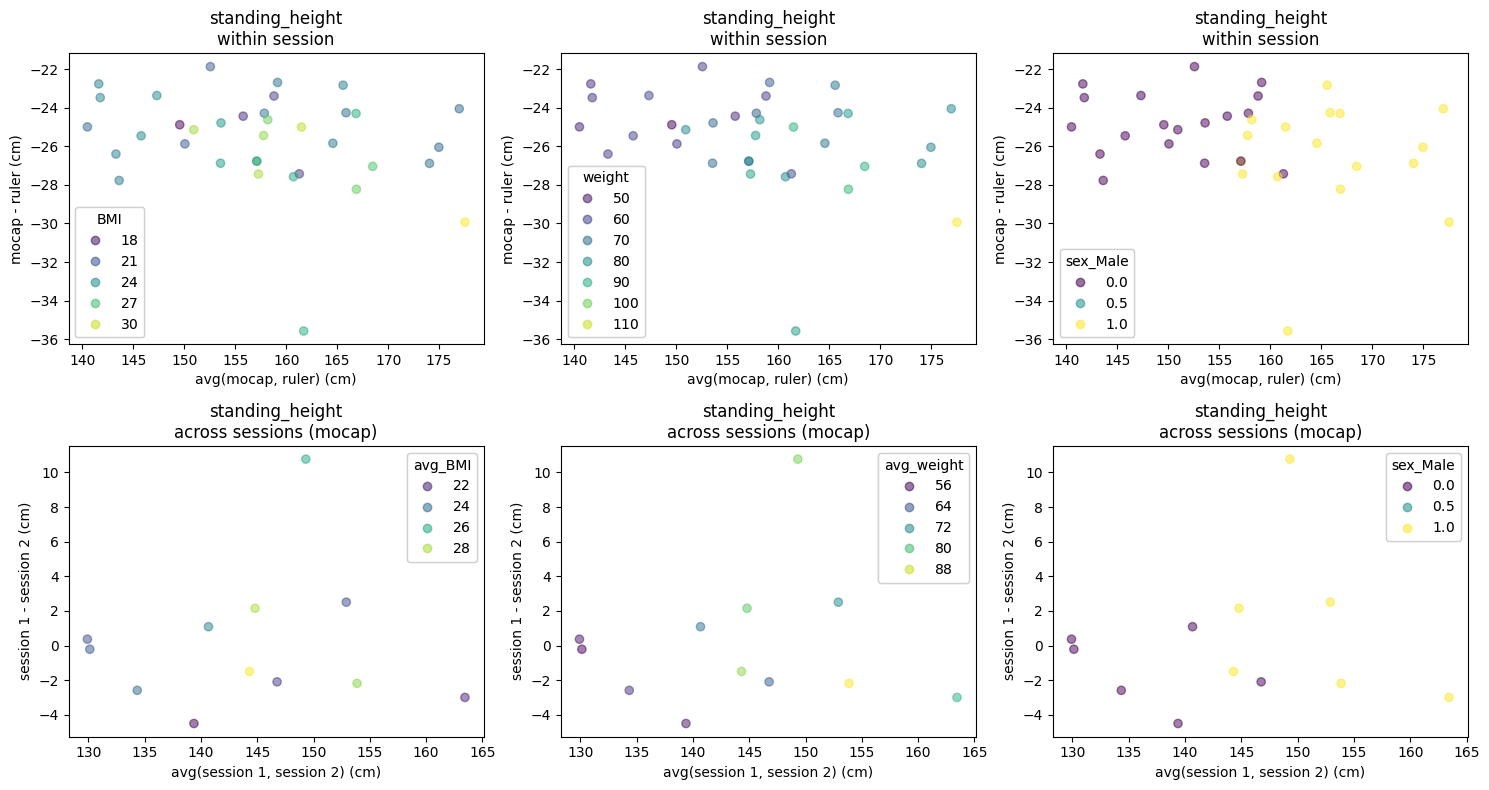

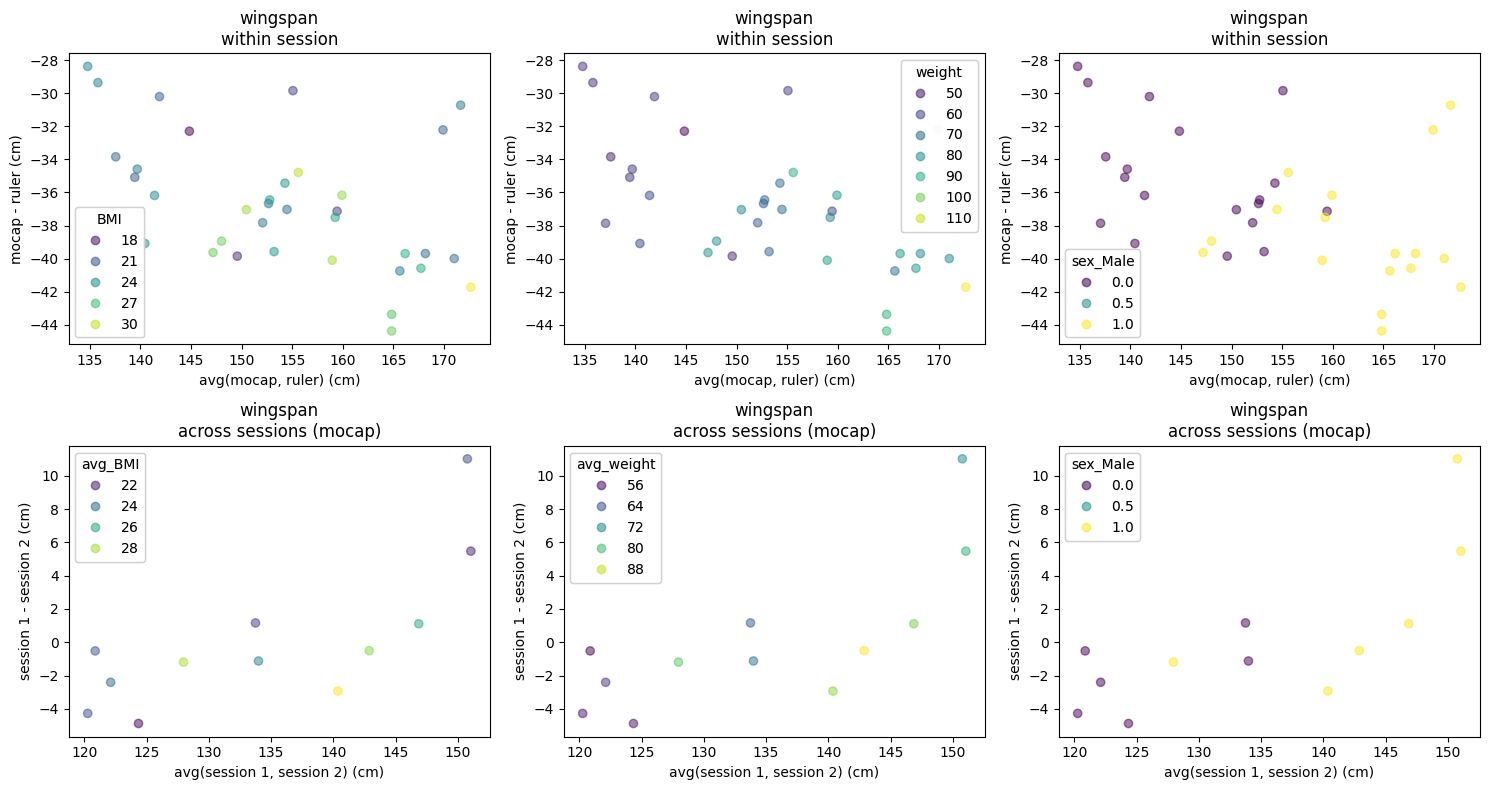

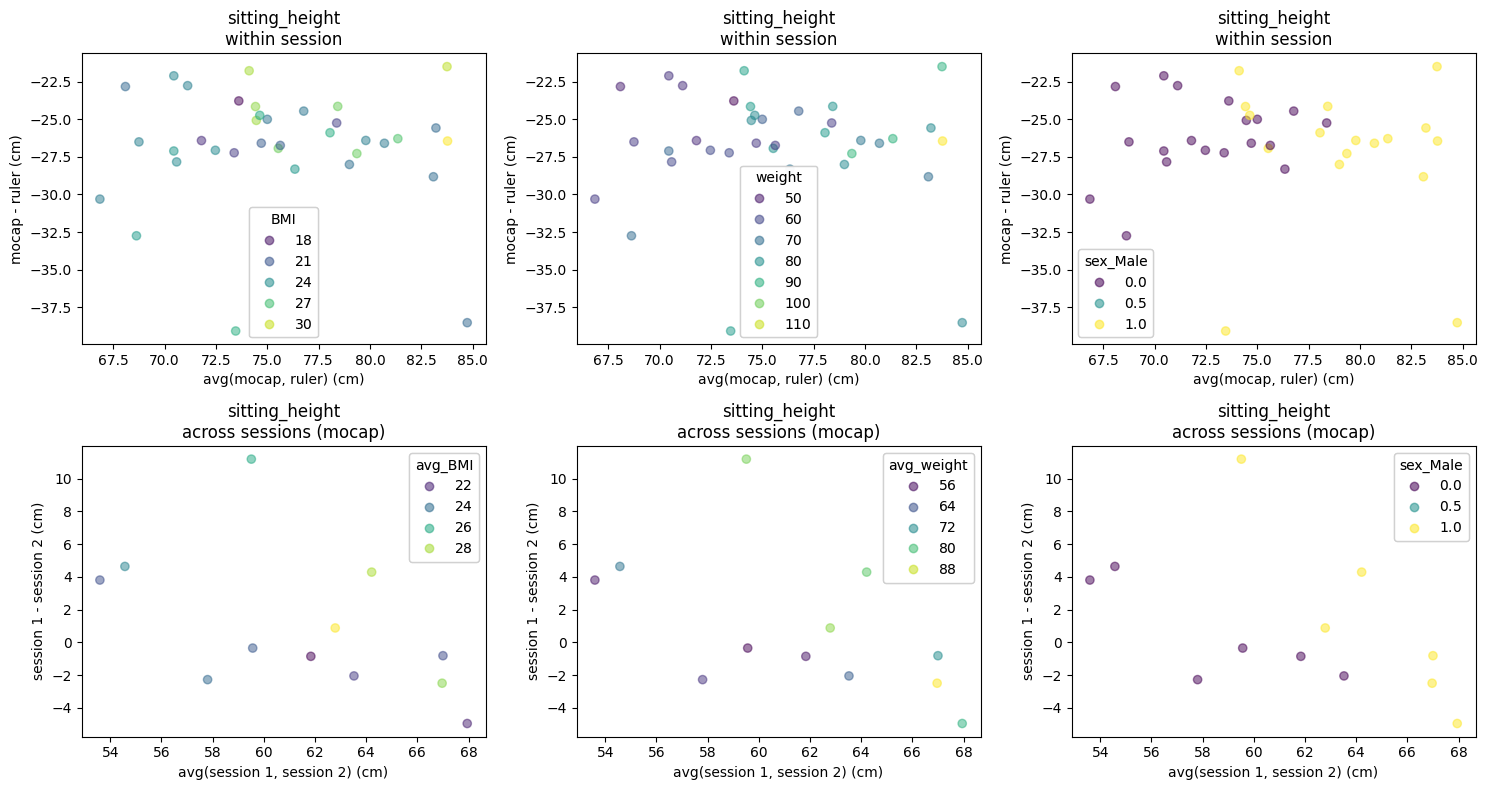

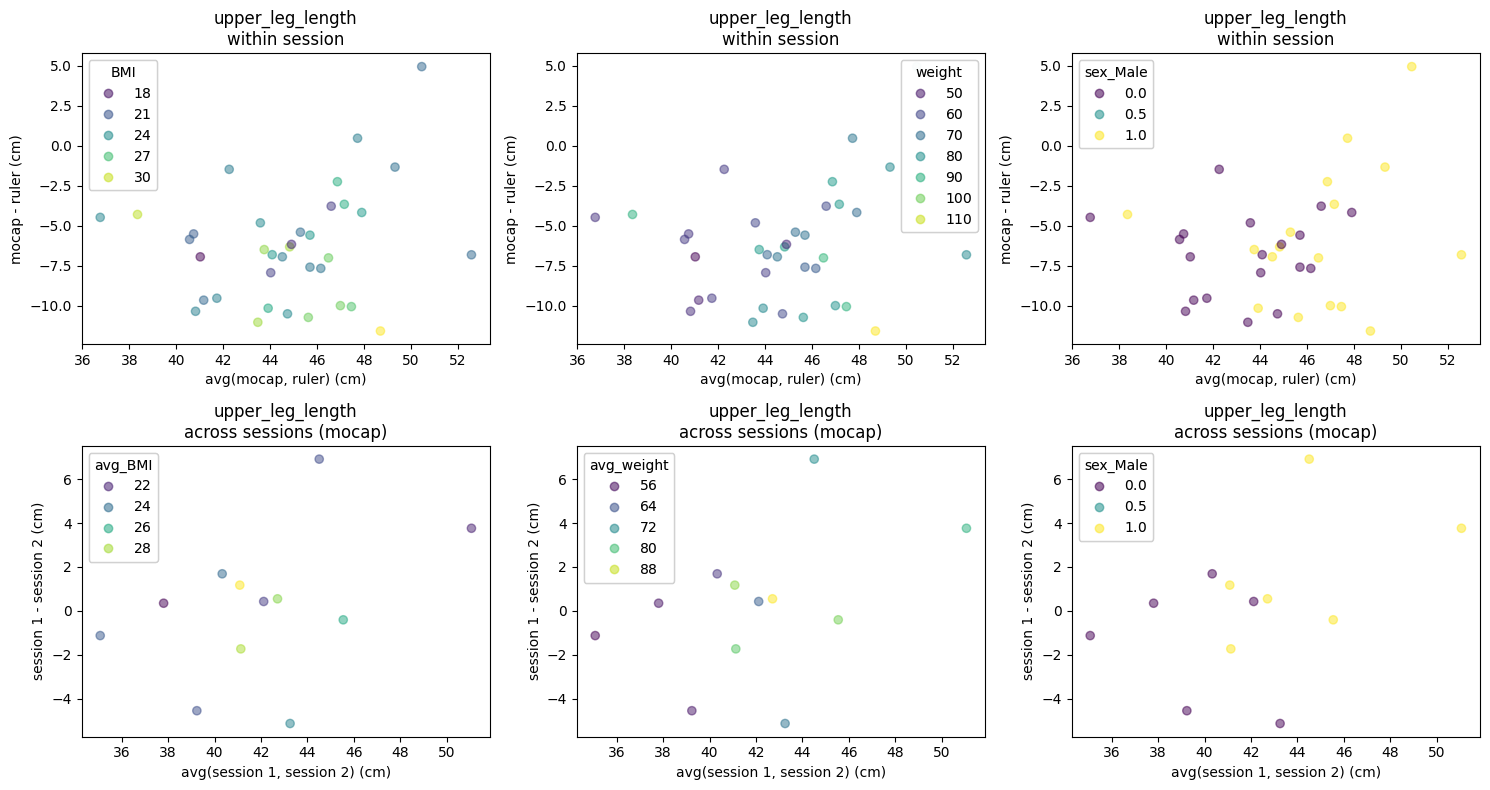

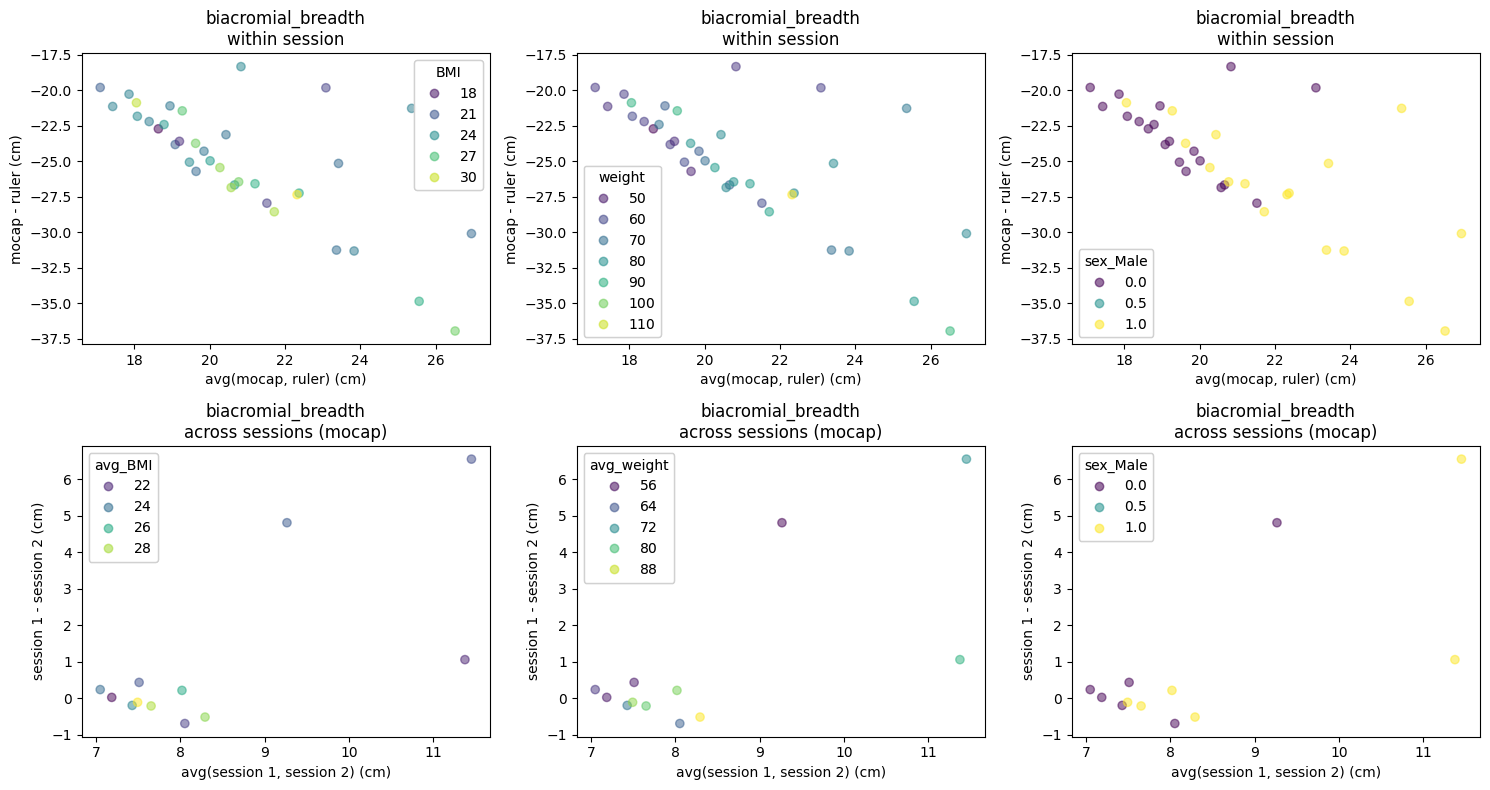

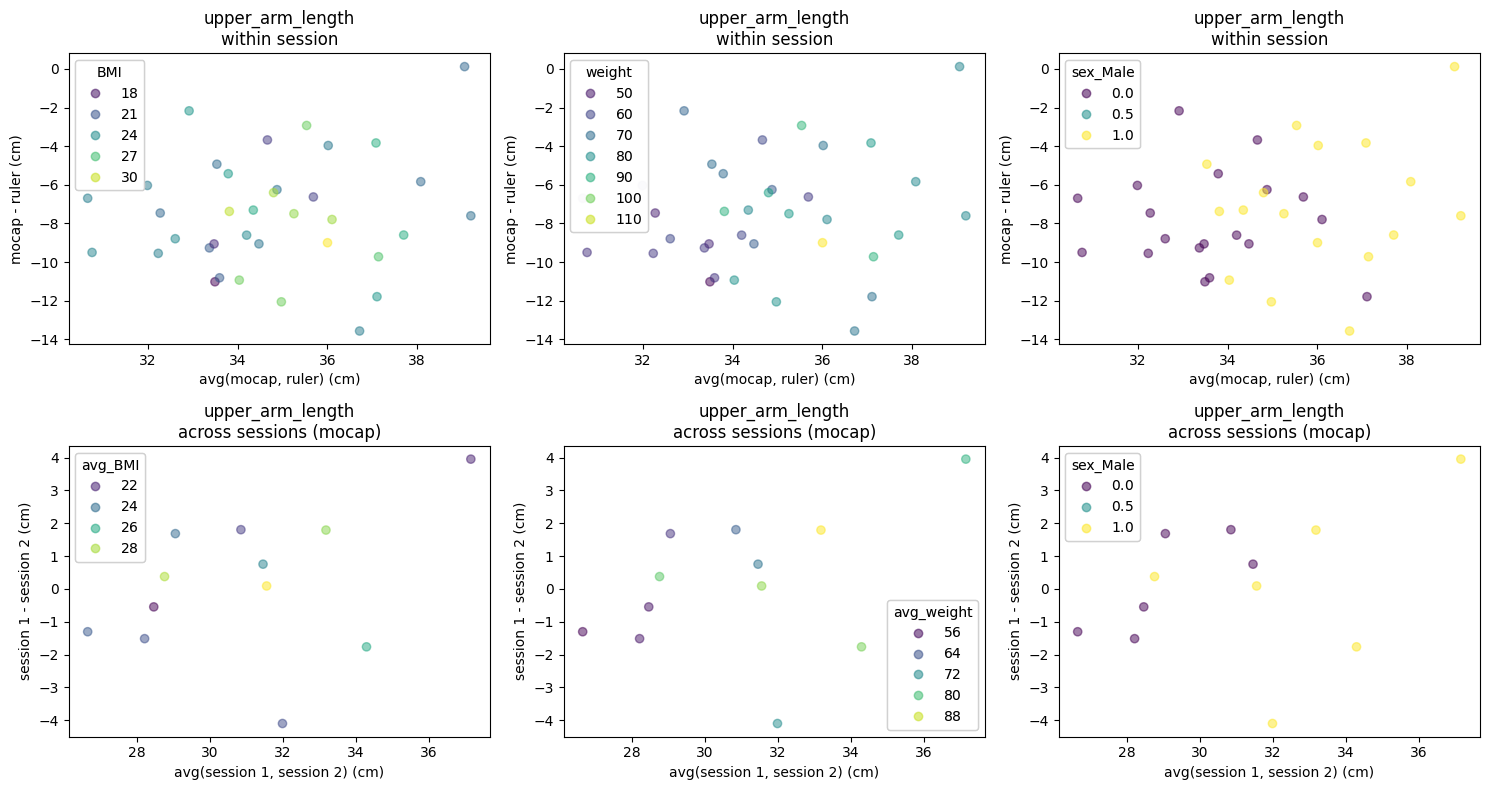

In [111]:
across_graph_dat = pd.get_dummies(audit_across_session, drop_first=True, dtype=int)
within_graph_dat = pd.get_dummies(audit_within_session, drop_first=True, dtype=int)

for measure in ['standing_height', 'wingspan', 'sitting_height', 'upper_leg_length', 
                    'biacromial_breadth', 'upper_arm_length']:
    
    fig, ax = plt.subplots(2, 3, figsize=(15,8))#, tight_layout = True)
    
    ## Within
    x = within_graph_dat['avg_' + measure]
    y = within_graph_dat['diff_' + measure]

    i = 0
    for var in ['BMI', 'weight', 'sex_Male']:
            
            scatter = ax[0, i].scatter(x, y, c=within_graph_dat[var], alpha=0.5)
            legend = ax[0, i].legend(*scatter.legend_elements(num=min(5, len(within_graph_dat[var].unique()))),
                               title=var)
            ax[0, i].add_artist(legend)
            ax[0, i].set_title(measure + '\nwithin session')
            ax[0, i].set_ylabel('mocap - ruler (cm)')
            ax[0, i].set_xlabel('avg(mocap, ruler) (cm)')
            i += 1
            #plt.show()


    ## Across
    x = across_graph_dat['avg_mocap_' + measure]
    y = across_graph_dat['diff_mocap_' + measure]

    i = 0
    for var in ['avg_BMI', 'avg_weight', 'sex_Male']:
            
            scatter = ax[1, i].scatter(x, y, c=across_graph_dat[var], alpha=0.5)
            legend = ax[1, i].legend(*scatter.legend_elements(num=min(5, len(across_graph_dat[var].unique()))),
                               title=var)
            ax[1, i].add_artist(legend)
            ax[1, i].set_title(measure + '\nacross sessions (mocap)')
            ax[1, i].set_ylabel('session 1 - session 2 (cm)')
            ax[1, i].set_xlabel('avg(session 1, session 2) (cm)')
            i += 1
            #plt.show()

    
    #plt.show()
    plt.tight_layout()
    plt.savefig('figures/' + measure + '.png', dpi=100, bbox_inches='tight')